# Experiments: Scalable GP Regression through State-Space Formulations

In [47]:
# Imports
import time
from pathlib import Path

import matplotlib.pyplot as plt  # plotting
import numpy as np  # arrays + math
from filterpy.kalman import KalmanFilter, rts_smoother
from scipy.optimize import minimize

# from scipy.linalg import expm
from scipy.special import gamma
from sklearn.gaussian_process import GaussianProcessRegressor  # the GP, from a package
from sklearn.gaussian_process.kernels import ConstantKernel, Matern  # Matern 3/2 kernel + sigma^2


In [48]:
plt.rcParams.update({
    "figure.dpi": 120,            # crisp inline rendering
    "savefig.dpi": 300,           # crisp if you export PNG
    "savefig.bbox": "tight",      # never clip labels on export
    "figure.figsize": (8, 4.5),   # one consistent default size

    "font.family": "serif",       # match your LaTeX thesis body text
    "mathtext.fontset": "cm",     # Computer-Modern math -> looks native in LaTeX
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,

    "axes.spines.top": True,      # full box border around every plot
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "axes.axisbelow": True,       # grid sits BEHIND the data

    "legend.frameon": False,      # no boxy legend outline
    "lines.linewidth": 1.8,
})

In [49]:
# Plot Style
COL_LINE = "indigo"
COL_DATA = "red"
COL_SAMPLES = "mediumpurple"
COL_VS = "mediumturquoise"

In [72]:
# Parameters
# Data
SEED = 0
N_TRAIN = 50
T_MIN, T_MAX = 0.0, 10.0
NOISE_STD = 0.2 # observation noise std (sigma_noise)

# GP hyperparameter starting values (sklearn tunes them from these)
SIGMA2_INIT = 0.5 # magnitude sigma^2
ELL_INIT = 1.0 # length-scale ell
NU = 1.5 # Matern smoothness; 1.5 = the p=1 case

# Plotting / demonstration
N_PLOT = 400 # dense grid points for the smooth posterior curves

# Scalability experiment
N_SWEEP = list(range(1000, 100001, 1000)) # n = 100, 200, ..., 5000
DENSE_MAX = 20001 # too much ram usage
TIMING_REPEATS = 1 # take the fastest of this many runs
SLOPE_FIT_FROM = 10000
# log-log slope is fit using only n >= this (small n is dominated by fixed overhead)

In [51]:
# Figure export helper — every plot is saved here as a PNG
GRAPHS_DIR = Path(r"C:\dev\University\Thesis\Scalable Gaussian Processes through State-Space Formulations\Graphs")
GRAPHS_DIR.mkdir(exist_ok=True)

def savefig(name):
    # save the current figure to Graphs/<name>.png (uses rcParams dpi=300, bbox=tight)
    plt.savefig(GRAPHS_DIR / f"{name}.png")

In [52]:
rng = np.random.default_rng(SEED)  # seed

def true_f(t):
    return np.sin(t) + 0.5 * np.sin(3 * t)  # true function

t_train = np.sort(rng.uniform(T_MIN, T_MAX, size=N_TRAIN))  # random points, sorted

y_train = true_f(t_train) + rng.normal(0, NOISE_STD, size=N_TRAIN)  # our model y = f + eps,
# eps ~ N(0, NOISE_STD^2)

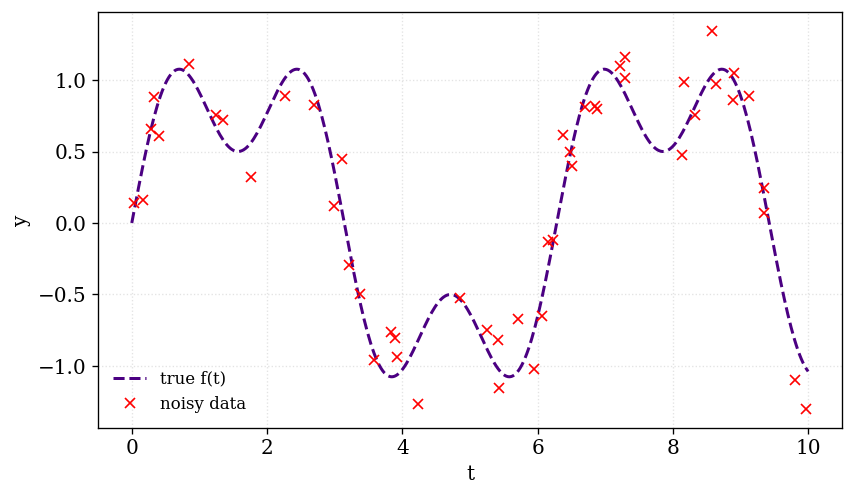

In [53]:
# plot
t_plot = np.linspace(T_MIN, T_MAX, N_PLOT)
plt.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", label="true f(t)")
plt.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
savefig("01_data")

# Gausian Process Regression

In [54]:
# GP: build, fit and predict
kernel = ConstantKernel(SIGMA2_INIT) * Matern(length_scale=ELL_INIT, nu=NU)  # sigma^2 * Matern_3/2
gp = GaussianProcessRegressor(kernel=kernel, alpha=NOISE_STD**2)   # alpha = noise variance
gp.fit(t_train.reshape(-1, 1), y_train) # fit to the data


print("fitted kernel:", gp.kernel_)

fitted kernel: 0.883**2 * Matern(length_scale=1.06, nu=1.5)


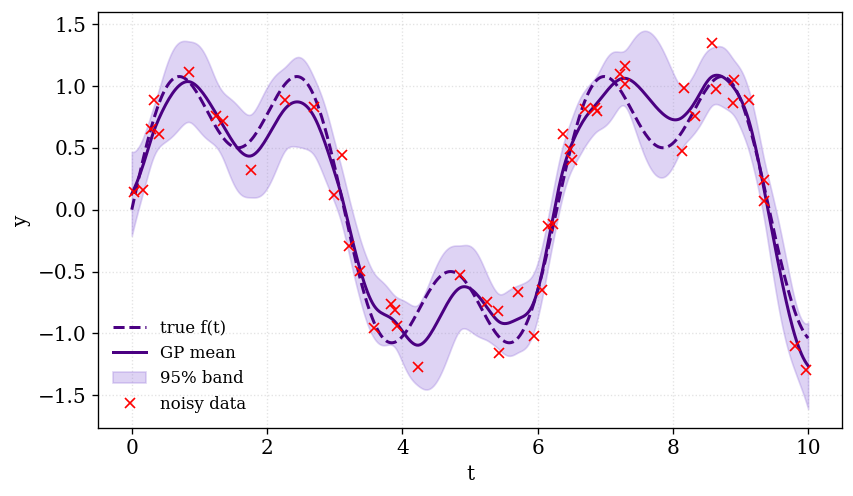

In [55]:
# Predict with the GP
mean, std = gp.predict(t_plot.reshape(-1, 1), return_std=True)

plt.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", label="true f(t)")
plt.plot(t_plot, mean, color=COL_LINE, label="GP mean")
plt.fill_between(t_plot, mean - 1.96 * std, mean + 1.96 * std, 
                 color=COL_SAMPLES, alpha=0.3, label="95% band")
plt.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
plt.legend()
plt.xlabel("t") 
plt.ylabel("y")
savefig("02_gp_posterior")

# State-Space Model

In [56]:
# Use the SAME hyperparameters the dense GP settled on, so the comparison is fair.
SIGMA2_FIT = gp.kernel_.k1.constant_value     # sigma^2 from the ConstantKernel
ELL_FIT    = gp.kernel_.k2.length_scale       # ell from the Matern part
print(f"using sigma^2 = {SIGMA2_FIT:.4f},  ell = {ELL_FIT:.4f}")


def matern32_ssm(sigma2, ell):
      lam = np.sqrt(3) / ell # lambda = sqrt(2*nu)/ell, nu=3/2
      F = np.array([[0.0,      1.0],
                    [-lam**2, -2*lam]]) # companion matrix F
      L = np.array([[0.0], [1.0]]) # noise enters only the 2nd component
      H = np.array([[1.0, 0.0]]) # f(t) = H x(t) = first component
      q = 4 * lam**3 * sigma2 # white-noise intensity
      P_inf = np.array([[sigma2, 0.0],
                        [0.0, lam**2 * sigma2]]) # stationary covariance
      return F, L, H, q, P_inf

F, L, H, q, P_inf = matern32_ssm(SIGMA2_FIT, ELL_FIT)
print("F =\n", F)
print("P_inf =\n", P_inf)

using sigma^2 = 0.7799,  ell = 1.0635
F =
 [[ 0.          1.        ]
 [-2.65235726 -3.25721185]]
P_inf =
 [[0.77992554 0.        ]
 [0.         2.06864117]]


In [57]:
# Discretize our state-space model — Section 6.2 CLOSED FORM (fast; avoids generic expm)
def discretize(Dt):
    lam = np.sqrt(3) / ELL_FIT # same lambda as the model
    e = np.exp(-lam * Dt)
    A = e * np.array([[1 + lam * Dt,        Dt        ],
                      [-lam**2 * Dt,    1 - lam * Dt   ]])   
    # = exp(F*Dt) for Matern 3/2, closed form
    Q = P_inf - A @ P_inf @ A.T # stationarity identity
    return A, Q

# example for the first time gap
Dt0 = t_train[1] - t_train[0]
A0, Q0 = discretize(Dt0)
print("Dt0 =", Dt0)
print("A0 =\n", A0)
print("Q0 =\n", Q0)

Dt0 = 0.13789135358381
A0 =
 [[ 0.97825945  0.11015576]
 [-0.29217244  0.61945878]]
Q0 =
 [[0.0084419  0.08176089]
 [0.08176089 1.20826504]]


In [58]:
def filter_nlml(sigma2, ell, t, y):
    # Negative log marginal likelihood via one forward Kalman pass, at given (sigma^2, ell).
    lam = np.sqrt(3) / ell
    F = np.array([[0.0, 1.0], [-lam**2, -2*lam]])
    P_inf = np.array([[sigma2, 0.0], [0.0, lam**2 * sigma2]])
    Hloc = np.array([[1.0, 0.0]])
    def disc(Dt):
        e = np.exp(-lam * Dt)
        A = e * np.array([[1 + lam*Dt, Dt], [-lam**2*Dt, 1 - lam*Dt]])
        Q = P_inf - A @ P_inf @ A.T
        return A, Q
    n = t.size
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.zeros(2); kf.P = P_inf.copy(); kf.H = Hloc; kf.R = NOISE_STD**2
    nll = 0.0
    for k in range(n):
        if k > 0:
            kf.F, kf.Q = disc(t[k] - t[k-1]); kf.predict()
        v = y[k] - (kf.H @ kf.x).item()           # innovation (before update)
        S = (kf.H @ kf.P @ kf.H.T).item() + kf.R  # innovation variance
        nll += 0.5 * (np.log(2*np.pi) + np.log(S) + v*v / S)
        kf.update(y[k])
    return nll

# optimize over log-parameters so sigma^2, ell stay positive; same start as the dense GP
def objective(log_params):
    sigma2, ell = np.exp(log_params)
    return filter_nlml(sigma2, ell, t_train, y_train)

res = minimize(objective, np.log([SIGMA2_INIT, ELL_INIT]), method="L-BFGS-B")
SIGMA2_SS, ELL_SS = np.exp(res.x)

SIGMA2_DENSE = gp.kernel_.k1.constant_value
ELL_DENSE    = gp.kernel_.k2.length_scale

print(f"dense GP fit:    sigma^2 = {SIGMA2_DENSE:.6f},  ell = {ELL_DENSE:.6f}")
print(f"filter MLE fit:  sigma^2 = {SIGMA2_SS:.6f},  ell = {ELL_SS:.6f}")
print(f"|sigma^2 diff| = {abs(SIGMA2_SS - SIGMA2_DENSE):.2e},  "
      f"|ell diff| = {abs(ELL_SS - ELL_DENSE):.2e}")

dense GP fit:    sigma^2 = 0.779926,  ell = 1.063517
filter MLE fit:  sigma^2 = 0.779925,  ell = 1.063517
|sigma^2 diff| = 1.89e-07,  |ell diff| = 6.40e-09


# Kalman Filter

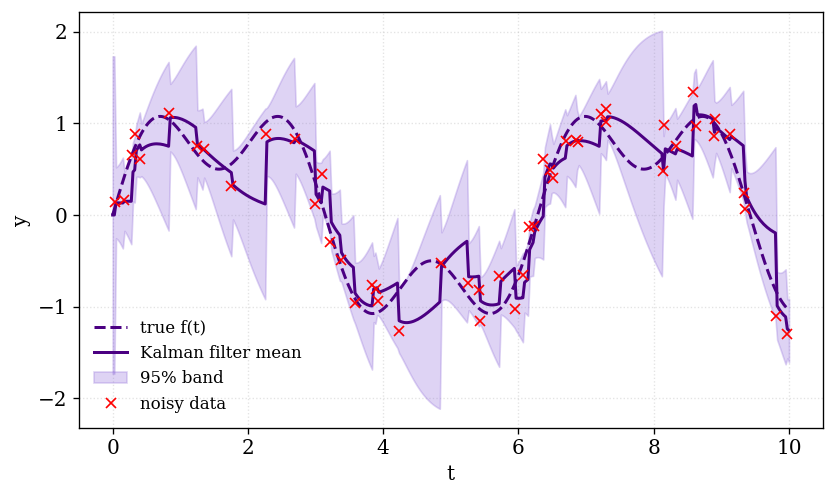

In [59]:
# We want to run a kalman filtering forward 
t_test = t_plot
t_all = np.concatenate([t_train, t_test])
y_all = np.concatenate([y_train, np.full(t_test.size, np.nan)])
is_obs = np.concatenate([np.ones(t_train.size, bool), np.zeros(t_test.size, bool)])
tag = np.concatenate([np.full(t_train.size, -1), np.arange(t_test.size)])

order = np.argsort(t_all, kind="stable") # sort everything by time
t_all, y_all, is_obs, tag = t_all[order], y_all[order], is_obs[order], tag[order]
# all of the above are now sorted 
test_pos = np.empty(t_test.size, int) # where each test point landed in the grid
test_pos[tag[tag >= 0]] = np.where(tag >= 0)[0]

# set up the filter with the stationary prior  x0 ~ N(0, P_inf)
kf = KalmanFilter(dim_x=2, dim_z=1)
kf.x = np.zeros(2) # prior mean  = 0
kf.P = P_inf.copy() # prior cov   = P_inf
kf.H = H
kf.R = NOISE_STD**2 # measurement noise variance

N = t_all.size
xs_f = np.zeros((N, 2))
Ps_f = np.zeros((N, 2, 2))    
# store filtered mean/cov each step
Fs = [np.eye(2)] * N 
Qs = [np.zeros((2, 2))] * N       
# store A_k, Q_k (the smoother needs them)

for k in range(N):
    if k > 0:
        A, Q = discretize(t_all[k] - t_all[k-1]) # per-step matrices (gaps vary)
        kf.F, kf.Q = A, Q
        Fs[k-1], Qs[k-1] = A, Q
        kf.predict() # prediction step
    if is_obs[k]:
        kf.update(y_all[k]) # update step (only where we have data)
    xs_f[k], Ps_f[k] = kf.x, kf.P

# plot the FILTERED posterior mean + 95% band of f at the test points
mean_filt = xs_f[test_pos, 0]
std_filt = np.sqrt(Ps_f[test_pos, 0, 0]) # filtered std of f (past only -> wide band)
plt.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", label="true f(t)")
plt.plot(t_test, mean_filt, color=COL_LINE, label="Kalman filter mean")
plt.fill_between(t_test, mean_filt - 1.96*std_filt, mean_filt + 1.96*std_filt,
                 color=COL_SAMPLES, alpha=0.3, label="95% band")
plt.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
savefig("03_kalman_filter")

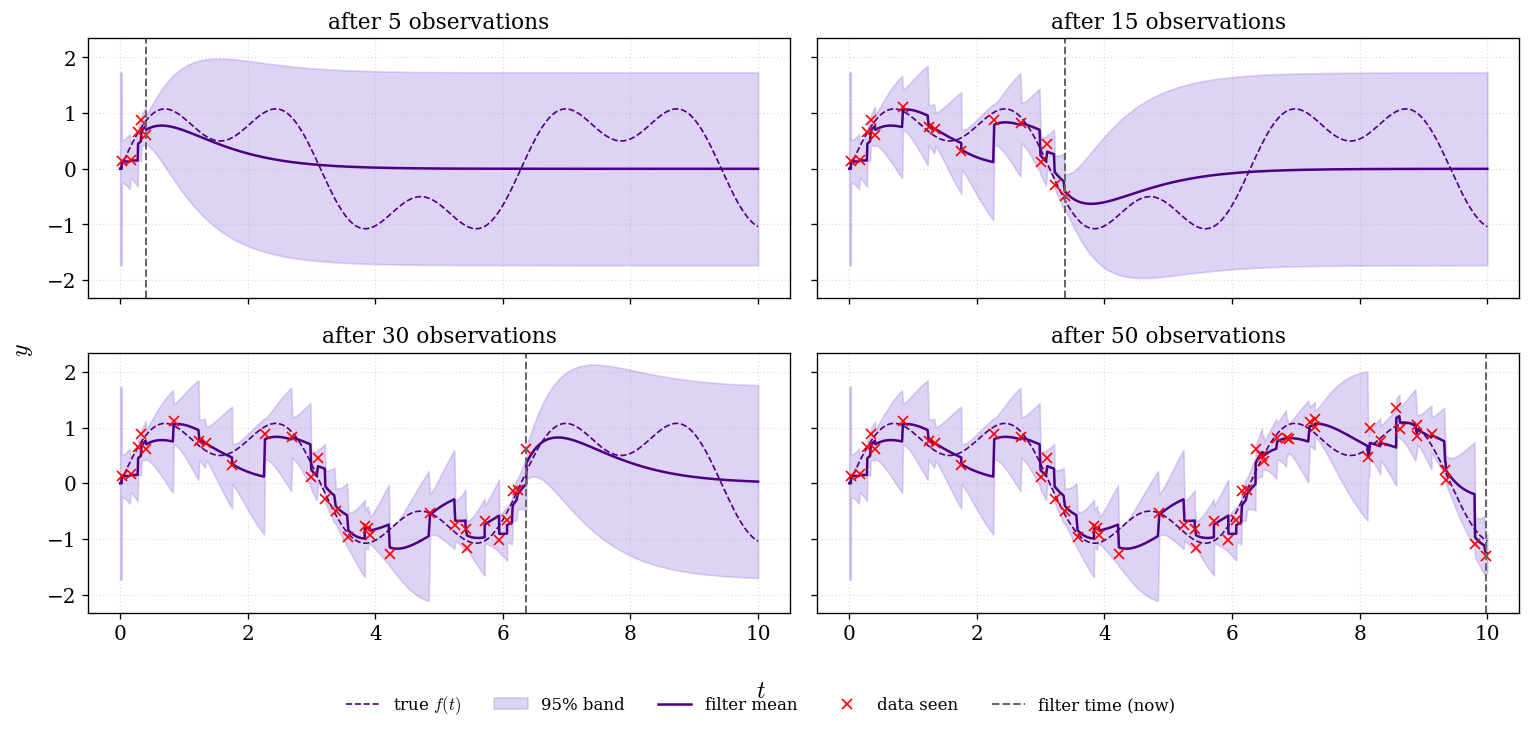

In [60]:
def filter_up_to(n_seen):
# Run the Kalman filter but assimilate only the first n_seen measurements (in time order)
    cutoff = np.sort(t_train)[n_seen - 1] if n_seen > 0 else -np.inf  # time of the last point seen
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.zeros(2)
    kf.P = P_inf.copy()
    kf.H = H
    kf.R = NOISE_STD**2
    m = np.zeros((N, 2))
    P = np.zeros((N, 2, 2))
    for k in range(N):
        if k > 0:
            A, Q = discretize(t_all[k] - t_all[k-1]); kf.F, kf.Q = A, Q; kf.predict()
        if is_obs[k] and t_all[k] <= cutoff:      # only fold in data up to the cutoff time
            kf.update(y_all[k])
        m[k], P[k] = kf.x, kf.P
    return m[:, 0], np.sqrt(P[:, 0, 0]), cutoff

counts = [5, 15, 30, 50] # how many observations seen in each panel
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, n_seen in zip(axes.ravel(), counts):
    mean_f, std_f, cutoff = filter_up_to(n_seen)
    ax.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", lw=1, label="true $f(t)$")
    ax.fill_between(t_all, mean_f - 1.96*std_f, mean_f + 1.96*std_f,
                      color=COL_SAMPLES, alpha=0.3, label="95% band")
    ax.plot(t_all, mean_f, color=COL_LINE, lw=1.5, label="filter mean")
    seen = t_train <= cutoff
    ax.plot(t_train[seen], y_train[seen], "x", color=COL_DATA, label="data seen")
    ax.axvline(cutoff, color="0.4", ls="--", lw=1.2, label="filter time (now)")
    ax.set_title(f"after {n_seen} observations")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.03))
fig.supxlabel("$t$"); fig.supylabel("$y$"); fig.tight_layout()
savefig("05_filter_snapshots")

# RTS Smoother 

max |mean_dense - mean_ss| = 5.190292640122607e-15
max |std_dense  - std_ss | = 3.219646771412954e-15


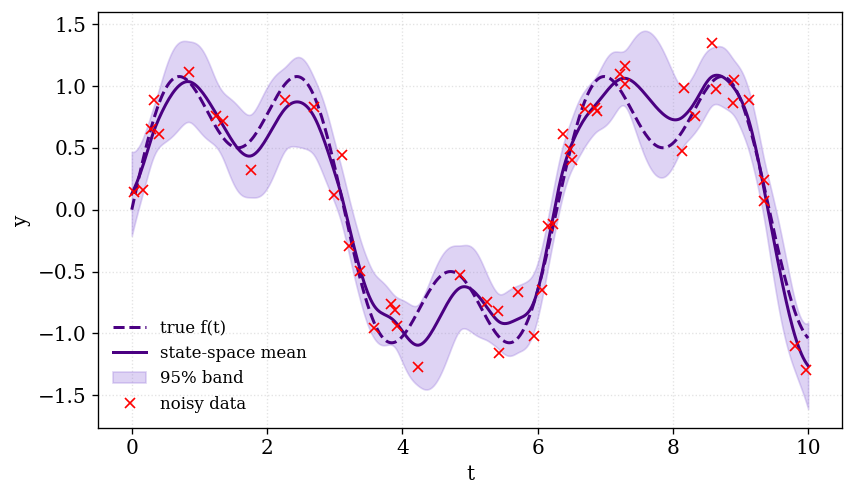

In [61]:
xs_s, Ps_s, _, _ = rts_smoother(xs_f, Ps_f, Fs, Qs)   # smooth using the saved filter results

# posterior mean and std of f at the test points
mean_ss = xs_s[test_pos, 0]               # smoothed mean of f
std_ss  = np.sqrt(Ps_s[test_pos, 0, 0])   # smoothed std  of f

# plot the smoothed posterior (this should match the dense GP)
plt.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", label="true f(t)")
plt.plot(t_test, mean_ss, color=COL_LINE, label="state-space mean")
plt.fill_between(t_test, mean_ss - 1.96*std_ss, mean_ss + 1.96*std_ss,
                   color=COL_SAMPLES, alpha=0.3, label="95% band")
plt.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
plt.legend(); plt.xlabel("t"); plt.ylabel("y");
savefig("04_state_space_smoother")

# the equivalence check: compare to the dense GP (mean, std from gp.predict earlier)
print("max |mean_dense - mean_ss| =", np.max(np.abs(mean - mean_ss)))
print("max |std_dense  - std_ss | =", np.max(np.abs(std  - std_ss)))

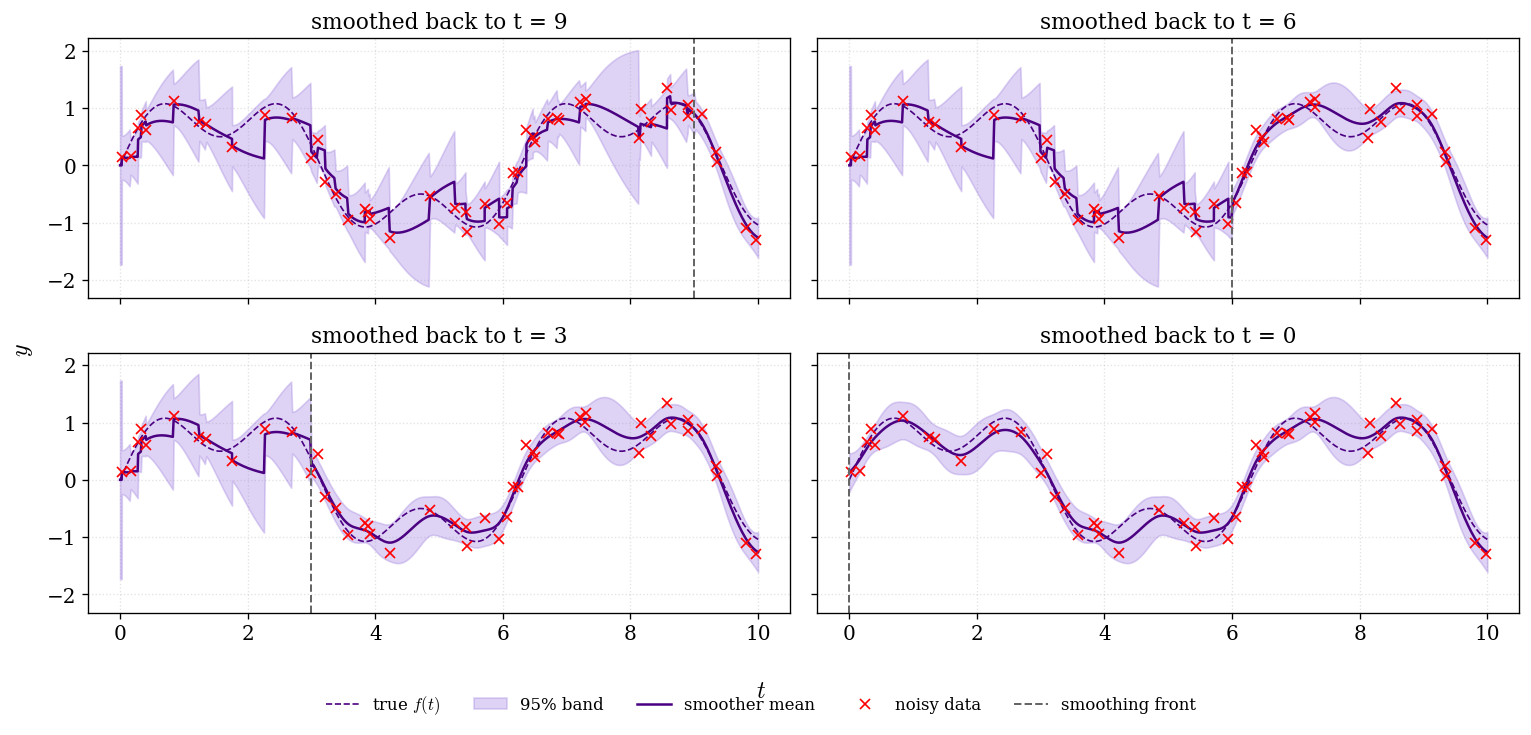

In [62]:
 # --- Backward (RTS) smoothing as snapshots ---
def smooth_back_to(cutoff_time):
    # Run the RTS smoother backward only down to cutoff_time; earlier points stay filtered
    j = np.searchsorted(t_all, cutoff_time) # grid index where smoothing stops
    m = xs_f[:, 0].copy()
    s = np.sqrt(Ps_f[:, 0, 0]).copy()  # start from the FILTERED result
    xs_suf, Ps_suf, _, _ = rts_smoother(xs_f[j:], Ps_f[j:], Fs[j:], Qs[j:]) # smooth the suffix
    m[j:] = xs_suf[:, 0] # overwrite the smoothed part
    s[j:] = np.sqrt(Ps_suf[:, 0, 0])
    return m, s

cutoffs = [9, 6, 3, 0]
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, c in zip(axes.ravel(), cutoffs):
    mean_b, std_b = smooth_back_to(c)
    ax.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", lw=1, label="true $f(t)$")
    ax.fill_between(t_all, mean_b - 1.96*std_b, mean_b + 1.96*std_b,
                      color=COL_SAMPLES, alpha=0.3, label="95% band")
    ax.plot(t_all, mean_b, color=COL_LINE, lw=1.5, label="smoother mean")
    ax.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
    ax.axvline(c, color="0.4", ls="--", lw=1.2, label="smoothing front")
    ax.set_title(f"smoothed back to t = {c}")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.03))
fig.supxlabel("$t$"); fig.supylabel("$y$"); fig.tight_layout()
savefig("06_smoother_snapshots")

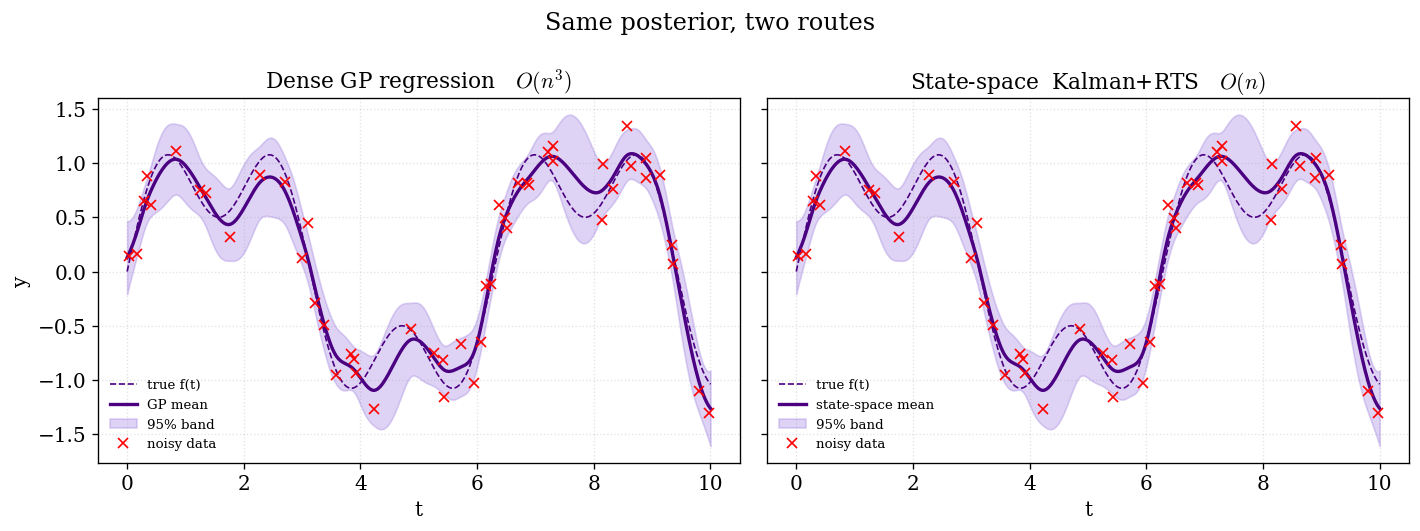

In [63]:
# --- Final product: dense GP regression vs state-space (Kalman+RTS) ---
# Both produce the SAME posterior (proven to ~1e-15 earlier); here we SEE it side by side.
fig, (ax_gp, ax_ss) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

# LEFT: dense GP regression  O(n^3)
ax_gp.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", lw=1, label="true f(t)")
ax_gp.plot(t_plot, mean, color=COL_LINE, lw=2, label="GP mean")
ax_gp.fill_between(t_plot, mean - 1.96*std, mean + 1.96*std,
                     color=COL_SAMPLES, alpha=0.3, label="95% band")
ax_gp.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
ax_gp.set_title("Dense GP regression   $O(n^3)$")
ax_gp.set_xlabel("t"); ax_gp.set_ylabel("y"); ax_gp.legend(fontsize=8)
# RIGHT: state-space smoother  O(n)
ax_ss.plot(t_plot, true_f(t_plot), color=COL_LINE, linestyle="--", lw=1, label="true f(t)")
ax_ss.plot(t_test, mean_ss, color=COL_LINE, lw=2, label="state-space mean")
ax_ss.fill_between(t_test, mean_ss - 1.96*std_ss, mean_ss + 1.96*std_ss,
                     color=COL_SAMPLES, alpha=0.3, label="95% band")
ax_ss.plot(t_train, y_train, "x", color=COL_DATA, label="noisy data")
ax_ss.set_title("State-space  Kalman+RTS   $O(n)$")
ax_ss.set_xlabel("t"); ax_ss.legend(fontsize=8)

fig.suptitle("Same posterior, two routes")
fig.tight_layout()
savefig("07_gp_vs_statespace")

n=  1000   gaussian-process-regression=  0.0717s   state-space=0.0800s
n=  2000   gaussian-process-regression=  0.7517s   state-space=0.1211s
n=  3000   gaussian-process-regression=  0.7278s   state-space=0.2056s
n=  4000   gaussian-process-regression=  2.1195s   state-space=0.3106s
n=  5000   gaussian-process-regression=  2.3773s   state-space=0.4316s
n=  6000   gaussian-process-regression=  4.9296s   state-space=0.3882s
n=  7000   gaussian-process-regression=  9.2939s   state-space=0.5274s
n=  8000   gaussian-process-regression= 12.3341s   state-space=1.5644s
n=  9000   gaussian-process-regression= 14.5426s   state-space=1.2577s
n= 10000   gaussian-process-regression= 16.5425s   state-space=1.0533s
n= 11000   gaussian-process-regression= 23.9844s   state-space=1.4643s
n= 12000   gaussian-process-regression= 26.4916s   state-space=0.7518s
n= 13000   gaussian-process-regression= 31.3864s   state-space=0.8627s
n= 14000   gaussian-process-regression= 45.7812s   state-space=1.0521s
n= 150

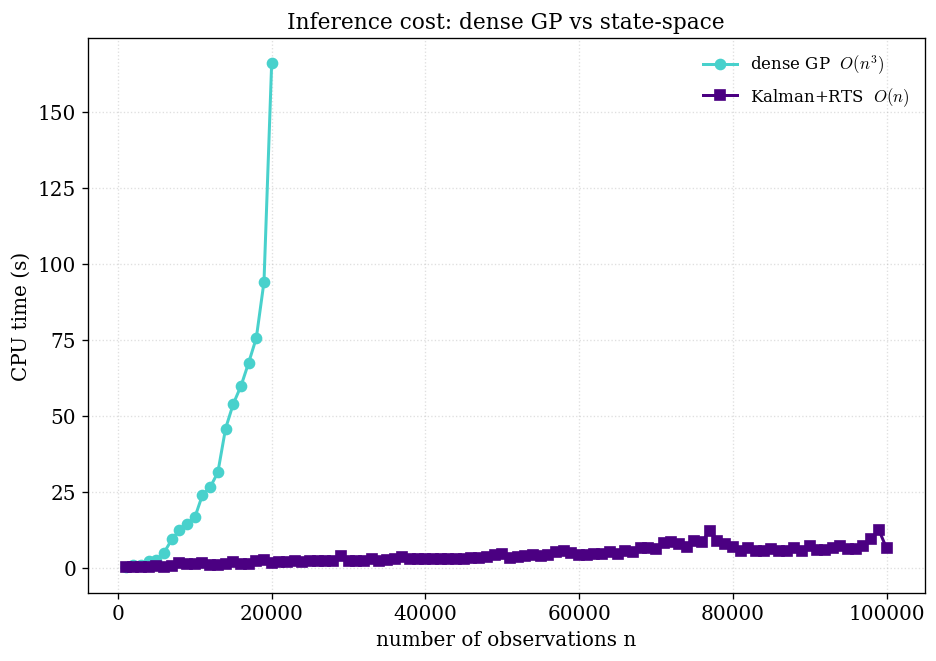

In [64]:
#  Inference cost: dense GP vs Kalman+RTS, as n grows
def ss_infer(t, y):
    # State-space inference (filter + smoother) over n observations. Returns smoothed state."""
    n = t.size
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.zeros(2)
    kf.P = P_inf.copy()
    kf.H = H
    kf.R = NOISE_STD**2
    xs = np.zeros((n, 2))
    Ps = np.zeros((n, 2, 2))
    Fs = [np.eye(2)] * n
    Qs = [np.zeros((2, 2))] * n
    for k in range(n):
        if k > 0:
            A, Q = discretize(t[k] - t[k-1])
            kf.F, kf.Q = A, Q
            Fs[k-1], Qs[k-1] = A, Q # filterpy convention (the fix from before)
            kf.predict()
        kf.update(y[k])
        xs[k], Ps[k] = kf.x, kf.P
    return rts_smoother(xs, Ps, Fs, Qs)

def best_time(fn): # fastest of TIMING_REPEATS runs
    best = np.inf
    for _ in range(TIMING_REPEATS):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best

ns_dense, dense_t, ns_ss, ss_t = [], [], [], []
for n in N_SWEEP:
    tt = np.sort(rng.uniform(T_MIN, T_MAX, size=n))
    yy = true_f(tt) + rng.normal(0, NOISE_STD, size=n)

    ns_ss.append(n)
    ss_t.append(best_time(lambda: ss_infer(tt, yy))) # state-space always

    if n <= DENSE_MAX: # dense only while tractable
        g = GaussianProcessRegressor(
            kernel=ConstantKernel(SIGMA2_FIT) * Matern(length_scale=ELL_FIT, nu=NU),
            alpha=NOISE_STD**2, optimizer=None)
        ns_dense.append(n)
        dense_t.append(best_time(lambda: g.fit(tt.reshape(-1, 1), yy)))
        print(f"n={n:6d}   gaussian-process-regression={dense_t[-1]:8.4f}s   state-space={ss_t[-1]:.4f}s")
    else:
        print(f"n={n:6d}   gaussian-process-regression=  (skipped)   state-space={ss_t[-1]:.4f}s")

ns_dense = np.array(ns_dense, float)
dense_t = np.array(dense_t)
ns_ss = np.array(ns_ss, float)
ss_t = np.array(ss_t)

# linear-scale plot: CPU time in seconds (1, 2, 3, ...), the dramatic blow-up
plt.figure(figsize=(9, 6))
plt.plot(ns_dense, dense_t, "o-", color=COL_VS, label="dense GP  $O(n^3)$")
plt.plot(ns_ss,    ss_t,    "s-", color=COL_LINE, label="Kalman+RTS  $O(n)$")
plt.xlabel("number of observations n")
plt.ylabel("CPU time (s)")
plt.title("Inference cost: dense GP vs state-space")
plt.legend()
plt.grid(True, ls=":", alpha=0.4)
savefig("08_inference_cost")

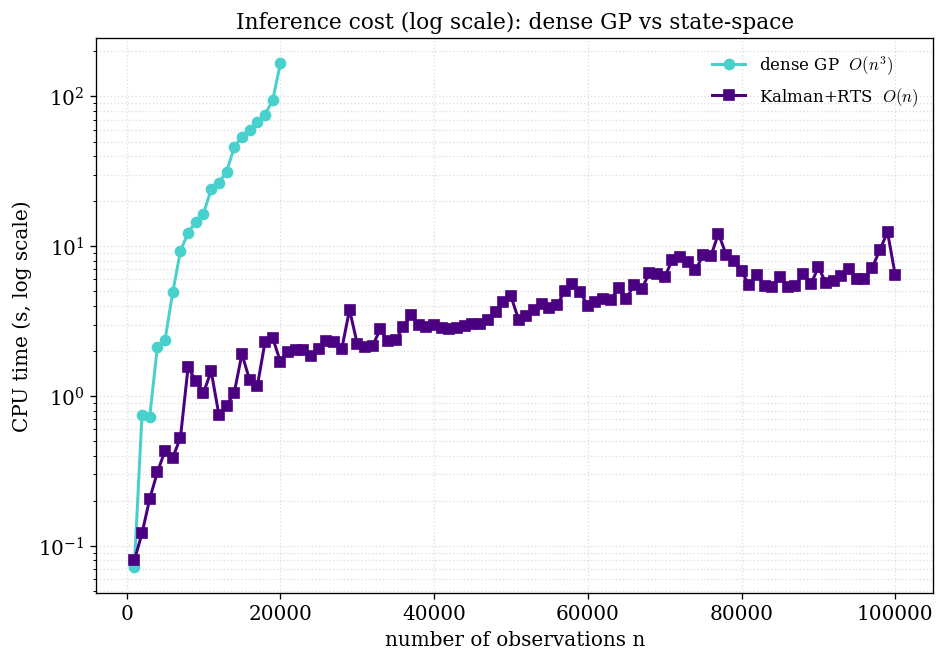

In [65]:
# log-scale version: same plot as above (x = number of observations),
# but y-axis is log so the O(n) line stays visible while the GP blows up
plt.figure(figsize=(9, 6))
plt.plot(ns_dense, dense_t, "o-", color=COL_VS,   label="dense GP  $O(n^3)$")
plt.plot(ns_ss,    ss_t,    "s-", color=COL_LINE, label="Kalman+RTS  $O(n)$")
plt.yscale("log")                       # only the y-axis is log; x stays linear in n
plt.xlabel("number of observations n")
plt.ylabel("CPU time (s, log scale)")
plt.title("Inference cost (log scale): dense GP vs state-space")
plt.legend()
plt.grid(True, which="both", ls=":", alpha=0.4)
savefig("09_inference_cost_log")

fitted slopes (n >= 10000):  dense GP = 2.89  (expect 3)   Kalman+RTS = 0.94  (expect 1)


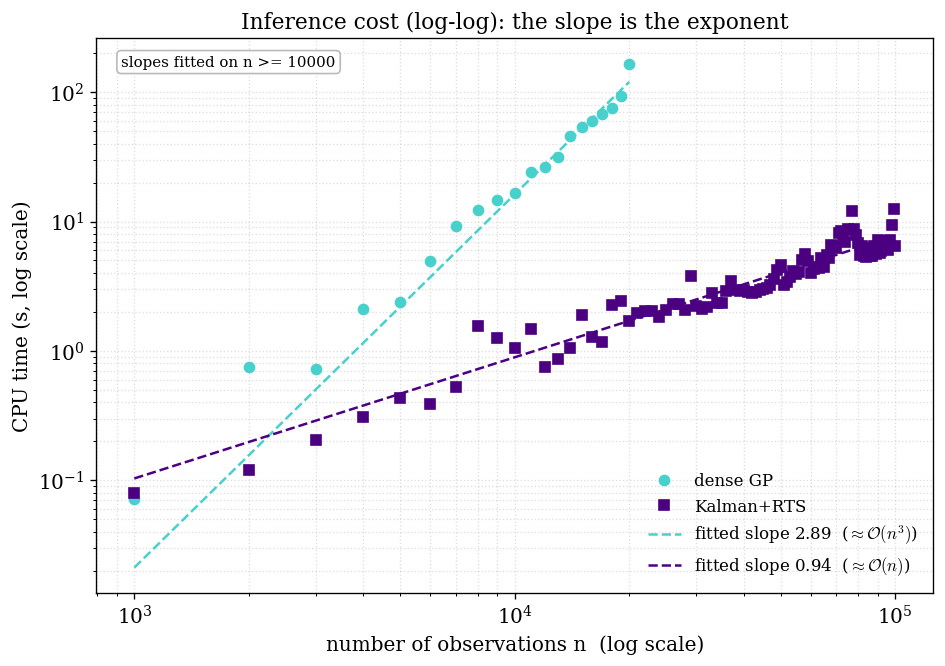

In [73]:
# log-log version: a power law t = c * n^p becomes a STRAIGHT LINE of slope p.
#   t = c n^p  ->  log t = log c + p log n  ->  slope on log-log axes = p.
# We fit this line on the large-n tail (n >= SLOPE_FIT_FROM); small n is dominated by
# fixed overhead. The fitted slope is the measured exponent (compare against 3 and 1).
def loglog_fit(ns, ts):
    # least-squares fit  log t = intercept + slope * log n  on the tail n >= SLOPE_FIT_FROM
    m = ns >= SLOPE_FIT_FROM
    slope, intercept = np.polyfit(np.log(ns[m]), np.log(ts[m]), 1)
    return slope, intercept

slope_dense, b_dense = loglog_fit(ns_dense, dense_t)
slope_ss,    b_ss    = loglog_fit(ns_ss,    ss_t)
print(f"fitted slopes (n >= {SLOPE_FIT_FROM}):  dense GP = {slope_dense:.2f}  (expect 3)   "
      f"Kalman+RTS = {slope_ss:.2f}  (expect 1)")

def fitline(ns, slope, intercept, color, label):
    # the fitted power law  t = exp(intercept) * n**slope, drawn across the full n range
    plt.loglog(ns, np.exp(intercept) * ns ** slope, "--", color=color, lw=1.5, label=label)

plt.figure(figsize=(9, 6))
plt.loglog(ns_dense, dense_t, "o", color=COL_VS,   label="dense GP")
plt.loglog(ns_ss,    ss_t,    "s", color=COL_LINE, label="Kalman+RTS")
fitline(ns_dense, slope_dense, b_dense, COL_VS,   fr"fitted slope {slope_dense:.2f}  ($\approx \mathcal{{O}}(n^3)$)")
fitline(ns_ss,    slope_ss,    b_ss,    COL_LINE, fr"fitted slope {slope_ss:.2f}  ($\approx \mathcal{{O}}(n)$)")

# the slopes above are fitted only on the large-n tail
plt.gca().text(
    0.03, 0.97,
    f"slopes fitted on n >= {SLOPE_FIT_FROM}",
    transform=plt.gca().transAxes, va="top", ha="left", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.7", alpha=0.9),
)

plt.xlabel("number of observations n  (log scale)")
plt.ylabel("CPU time (s, log scale)")
plt.title("Inference cost (log-log): the slope is the exponent")
plt.legend(loc="lower right")
plt.grid(True, which="both", ls=":", alpha=0.4)
savefig("09b_inference_cost_loglog")

## Matérn kernel and its spectral density

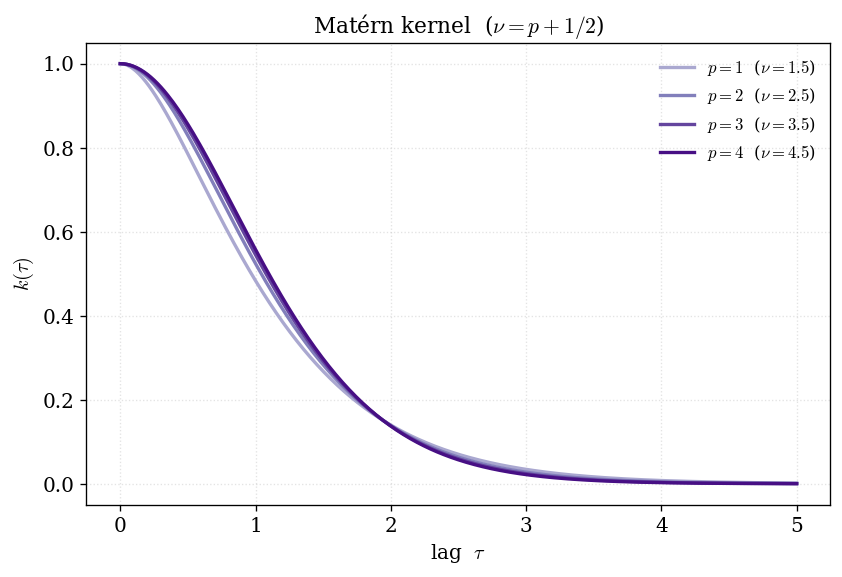

In [67]:
# --- Matérn kernel at different smoothness p  (nu = p + 1/2) ---
# sklearn's Matern object evaluates k(tau) for us, Bessel-function math and all.
P_VALUES   = [1, 2, 3, 4]      # nu = 3/2, 5/2, 7/2, 9/2
KERNEL_ELL = 1.0               # length-scale ell (fixed so the curves are comparable)
TAU_MAX    = 5.0               # plot lag |tau| from 0 to here
N_CURVE    = 400               # points per curve

taus   = np.linspace(0.0, TAU_MAX, N_CURVE)                       # lags tau >= 0
shades = plt.cm.Purples(np.linspace(0.45, 0.95, len(P_VALUES)))  # light -> dark purple

plt.figure(figsize=(8, 5))
for p, col in zip(P_VALUES, shades):
    nu   = p + 0.5
    kern = Matern(length_scale=KERNEL_ELL, nu=nu)                 # sklearn kernel object
    k_tau = kern(np.array([[0.0]]), taus.reshape(-1, 1)).ravel()  # k(0, tau) at each lag
    plt.plot(taus, k_tau, color=col, lw=2, label=rf"$p={p}$  ($\nu={nu}$)")

plt.xlabel(r"lag  $\tau$")
plt.ylabel(r"$k(\tau)$")
plt.title(r"Matérn kernel  ($\nu = p + 1/2$)")
plt.legend()
savefig("10_matern_kernel")

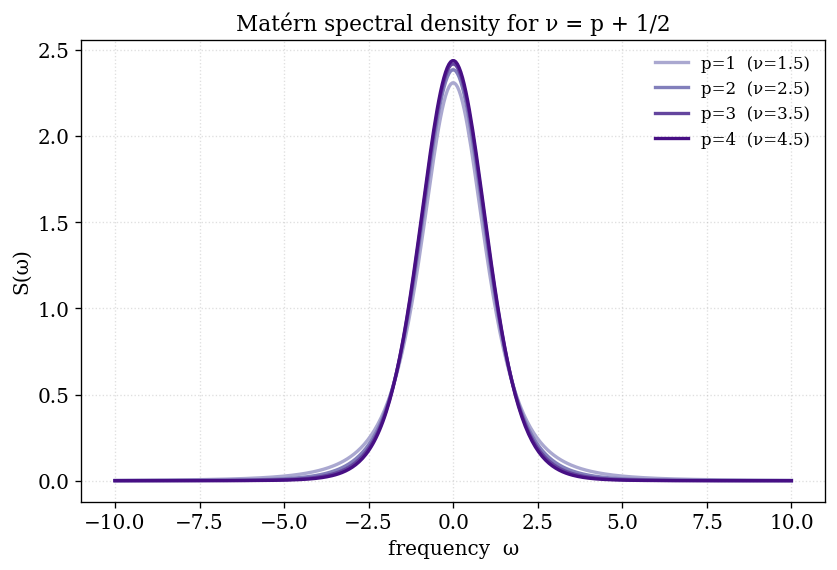

In [68]:
# --- Matérn spectral density S(omega) for the same p (your closed form) ---
# No package computes S(omega) directly: it's your rational formula (thesis eq.).
# scipy.special.gamma just supplies the Gamma constants.

OMEGA_MAX     = 10.0           # plot omega over [-OMEGA_MAX, OMEGA_MAX]
KERNEL_SIGMA2 = 1.0            # magnitude sigma^2

def matern_spectral_density(omega, p, ell, sigma2):
    nu  = p + 0.5
    lam = np.sqrt(2 * nu) / ell                                    # lambda = sqrt(2 nu)/ell
    const = sigma2 * 2 * np.sqrt(np.pi) * gamma(p + 1) / gamma(p + 0.5) * lam ** (2 * p + 1)
    return const * (lam ** 2 + omega ** 2) ** (-(p + 1))           # rational in omega^2

omegas = np.linspace(-OMEGA_MAX, OMEGA_MAX, N_CURVE)

plt.figure(figsize=(8, 5))
for p, col in zip(P_VALUES, shades):
    S = matern_spectral_density(omegas, p, KERNEL_ELL, KERNEL_SIGMA2)
    plt.plot(omegas, S, color=col, lw=2, label=f"p={p}  (ν={p + 0.5})")

plt.xlabel("frequency  ω"); plt.ylabel("S(ω)")
plt.title("Matérn spectral density for ν = p + 1/2")
plt.legend(); plt.grid(True, ls=":", alpha=0.4)
savefig("11_matern_spectral_density")
# tip: plt.yscale("log") makes the high-frequency tails (the smoothness) easier to see

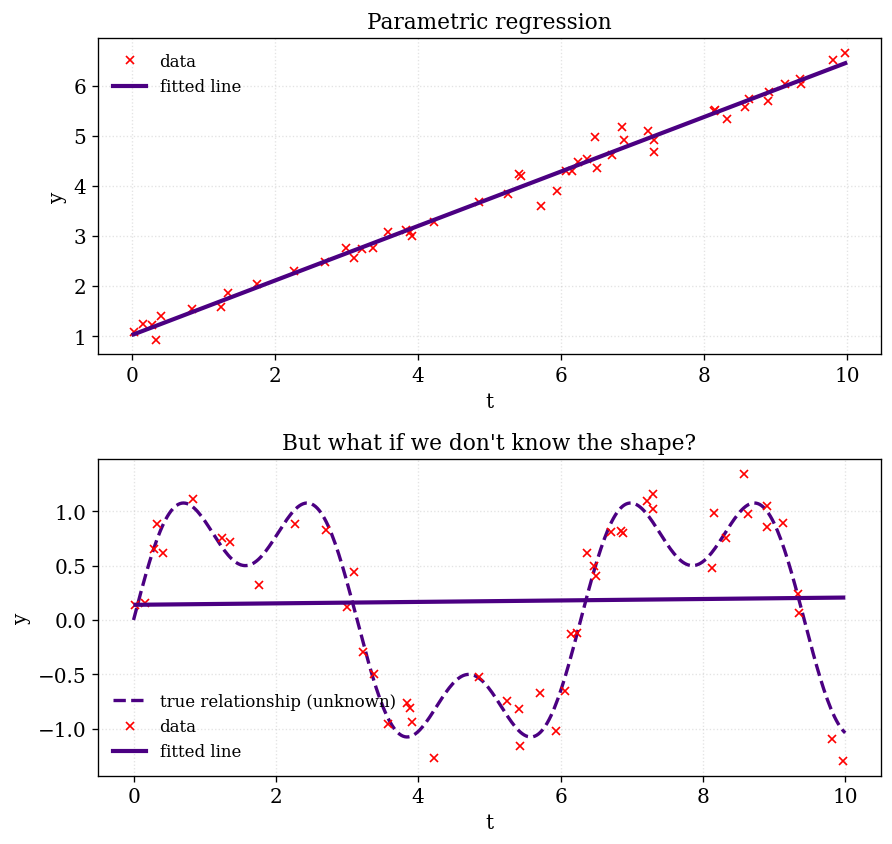

In [69]:
rng = np.random.default_rng(1)

def fit_line(ax, t, y):                        # LINEAR REGRESSION in *both* panels
    a, b = np.polyfit(t, y, 1)                 # degree-1 least squares
    ax.plot(t, y, "x", color=COL_DATA, ms=5, label="data")
    ax.plot(t, a*t + b, color=COL_LINE, lw=2.5, label="fitted line")

fig, (axT, axB) = plt.subplots(2, 1, figsize=(7.6, 7.2))   # stacked; no sharey, the two truths live on different ranges

# TOP — the relationship really IS a line: fixing the shape upfront works.
y_lin = 0.55 * t_train + 1.0 + rng.normal(0, NOISE_STD, t_train.size)
fit_line(axT, t_train, y_lin)
axT.set_title("Parametric regression")

# BOTTOM — SAME linear regression on the notebook's real data; the true shape (true_f) is unknown and curves -> it fails
axB.plot(t_plot, true_f(t_plot), "--", color=COL_LINE, lw=2, label="true relationship (unknown)")
fit_line(axB, t_train, y_train)
axB.set_title("But what if we don't know the shape?")

for ax in (axT, axB):
    ax.set_xlabel("t"); ax.legend(loc="upper left")
    ax.set_ylabel("y"); axB.legend(loc="lower left")                      # both get a y-label now they're stacked
fig.tight_layout()
savefig("00_why_parametric_fails")